In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

np.random.seed(42)
torch.manual_seed(42)

In [2]:
data = {
    'temperature': [10, 15, 22, 25, 28, 35, 38],
    'humidity': [30, 40, 50, 55, 60, 70, 80],
    'y': [0, 0, 1, 1, 1, 0, 0]
}

df = pd.DataFrame(data)
df

,temperature,humidity,y
0,10,30,0
1,15,40,0
2,22,50,1
3,25,55,1
4,28,60,1
5,35,70,0
6,38,80,0


In [3]:
X_raw = df[['temperature', 'humidity']].to_numpy(dtype=np.float32)

X_raw

array([[10., 30.],
       [15., 40.],
       [22., 50.],
       [25., 55.],
       [28., 60.],
       [35., 70.],
       [38., 80.]], dtype=float32)

In [4]:
y = df['y'].to_numpy(dtype=np.float32).reshape(-1, 1)

y

array([[0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.]], dtype=float32)

In [5]:
X_mean = X_raw.mean(axis=0, keepdims=True)
X_std = X_raw.std(axis=0, keepdims=True)

print(f'X_mean={X_mean}, X_std={X_std}')

X_mean=[[24.714285 55.      ]], X_std=[[ 9.345959 15.811388]]


In [6]:
X_norm = (X_raw - X_mean) / X_std

X_norm

array([[-1.5744008 , -1.5811388 ],
       [-1.0394102 , -0.9486833 ],
       [-0.29042336, -0.31622776],
       [ 0.03057098,  0.        ],
       [ 0.35156533,  0.31622776],
       [ 1.1005522 ,  0.9486833 ],
       [ 1.4215466 ,  1.5811388 ]], dtype=float32)

In [7]:
X_tensor = torch.tensor(X_norm, dtype=torch.float32)

X_tensor

tensor([[-1.5744, -1.5811],
        [-1.0394, -0.9487],
        [-0.2904, -0.3162],
        [ 0.0306,  0.0000],
        [ 0.3516,  0.3162],
        [ 1.1006,  0.9487],
        [ 1.4215,  1.5811]])

In [8]:
y_tensor = torch.tensor(y, dtype=torch.float32)

y_tensor

tensor([[0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.]])

In [9]:
X1_norm = X_tensor[:, [0]]
X2_norm = X_tensor[:, [1]]

print(f'X1_norm={X1_norm}')
print(f'X2_norm={X2_norm}')

X1_norm=tensor([[-1.5744],
        [-1.0394],
        [-0.2904],
        [ 0.0306],
        [ 0.3516],
        [ 1.1006],
        [ 1.4215]])
X2_norm=tensor([[-1.5811],
        [-0.9487],
        [-0.3162],
        [ 0.0000],
        [ 0.3162],
        [ 0.9487],
        [ 1.5811]])


In [10]:
# --- 히든 뉴런 1 파라미터(H_hidden_1, z_hidden_1을 만드는 뉴런) ---
a11 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)  # X1(온도) -> 히든 뉴런 1
a12 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)  # X2(습도) -> 히든 뉴런 2
b1 = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)                       # 히든 뉴런 1 편향

# --- 히든 뉴런 2 파라미터(H_hidden_2, z_hidden_2을 만드는 뉴런) ---
a21 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)  # X1(온도) -> 히든 뉴런 2
a22 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)  # X2(습도) -> 히든 뉴런 2
b2 = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)                       # 히든 뉴런 2 편향

# --- 출력층 파라미터(H_output, z_output을 만드는 뉴런) ---
a31 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)  # z_hidden_1 -> 출력층 가중치
a32 = torch.tensor(np.random.randn() * 0.1, dtype=torch.float32, requires_grad=True)  # z_hidden_2 -> 출력층 가중치
b3 = torch.tensor(0.0, dtype=torch.float32, requires_grad=True)                       # 출력층 편향

print('초기 a11:', a11.item(), '| requires_grad:', a11.requires_grad)

초기 a11: 0.049671415239572525 | requires_grad: True


In [11]:
def bce_cost_torch(y, z_output):
    epsilon = 1e-7   # 0에 아주 가까운 작은 안전값
    
    # z_output를 [epsilon, 1-epsilon] 범위로 살짝 잘라 log(0)을 막습니다.
    z_output = torch.clamp(z_output, epsilon, 1 - epsilon)
    
    # 정답이 1일 때(y*log z_output)와 0일 때((1-y)*log(1-z_output))를 더해 평균낸 뒤, -로 뒤집어 Cost로.
    cost = -torch.mean(
        y * torch.log(z_output) + (1 - y) * torch.log(1 - z_output)
    )
    return cost

In [12]:
# 학습 전에 forward를 한 번 실행해서 shape와 cost를 확인합니다. (확인용)
# 이번 노트북에서는 초보자가 순전파 계산 흐름을 직접 볼 수 있도록 
# 함수를 호출하지 않고 순전파 식을 직접 작성합니다.

# 히든 뉴런 1 
H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1
z_hidden_1 = torch.sigmoid(H_hidden_1)

# 히든 뉴런 2
H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b2
z_hidden_2 = torch.sigmoid(H_hidden_2)

# 출력층
H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
z_output = torch.sigmoid(H_output)

cost = bce_cost_torch(y_tensor, z_output)

print('z_output shape:', z_output.shape)
print('초기 cost:', cost.item())

z_output shape: torch.Size([7, 1])
초기 cost: 0.6915522217750549


In [13]:
# cost.backward()를 실행하면 PyTorch가 cost에서 출발해
# z_output -> H_output -> z_hidden_1, z_hidden_2 -> H_hidden_1, H_hidden_2 -> 각 파라미터
# 방향으로 거꾸로 따라가며 gradient를 계산합니다.

# 이때 PyTorch는 순전파 때 만들어진 계산 그래프를 이용합니다.

# 계산된 gradient는 새 변수로 반환되는 것이 아니라,
# a11.grad, a12.grad, ..., b3.grad 안에 자동으로 저장됩니다.
cost.backward()

# .grad에 gradient가 자동으로 채워진 것을 확인합니다. (대표 5개)
print('a11.grad:', a11.grad)
print('a12.grad:', a12.grad)
print('b1.grad:', b1.grad)
print('a31.grad:', a31.grad)
print('b3.grad:', b3.grad)

# 학습을 시작하기 전에 gradient를 모두 0으로 비웁니다.
# gradient는 계속 누적되므로, 초기화하지 않으면 앞의 값이 섞입니다.
params = [a11, a12, b1, a21, a22, b2, a31, a32, b3]
for p in params:
    if p.grad is not None:   # 안전장치: grad가 아직 없으면 건너뜁니다.
        p.grad.zero_()

a11.grad: tensor(7.8709e-05)
a12.grad: tensor(2.0380e-06)
b1.grad: tensor(-0.0004)
a31.grad: tensor(0.0326)
b3.grad: tensor(0.0656)


In [14]:
learning_rate = 0.5
epochs = 3000
cost_history = []

In [15]:
# 학습할 파라미터 9개를 리스트 하나로 모아 둡니다. (아래에서 반복문으로 한 번에 다룸)
params = [a11, a12, b1, a21, a22, b2, a31, a32, b3]

# 학습 과정을 확인하기 위한 기록용 리스트입니다.
# 대표 epoch마다 cost, 대표 파라미터, 대표 gradient를 저장합니다.
training_log = []

# for epoch in range(epochs): 같은 학습 과정을 epochs(3000)번 반복합니다.
for epoch in range(epochs):
    # (1) 순전파: 함수 호출이 아니라 식을 직접 작성합니다.
    #     초보자가 계산 흐름을 눈으로 따라갈 수 있도록 매 epoch 식을 그대로 씁니다.
    # 히든 뉴런 1
    H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1
    z_hidden_1 = torch.sigmoid(H_hidden_1)
    
    # 히든 뉴런 2
    H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b2
    z_hidden_2 = torch.sigmoid(H_hidden_2)
    
    # 출력층
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
    z_output = torch.sigmoid(H_output)
    
    # (2) Cost 계산
    #     .item()은 Tensor 안의 숫자 하나를 Python 숫자로 꺼내는 것, .append는 리스트 끝에 추가.
    cost = bce_cost_torch(y_tensor, z_output)
    cost_history.append(cost.item())
    
    # (3) gradient 자동 계산(PyTorch autograd)
    # cost.backward()를 실행하면 pyTorch가 cost에서 출발해
    # z_output -> H_output -> z_hidden_1, z_hidden_2 -> H_hidden_1, H_hidden_2 -> 각 파라미터
    # 방향으로 거꾸로 따라가며 gradient를 계산합니다.
    
    # 계산된 gradient는 새 변수로 반환되는 것이 아니라,
    # a11.grad, a12.grad, ..., b3.grad 안에 자동으로 저장됩니다.
    cost.backward()
    
    # (4) 대표 epoch에서 cost, 파라미터, gradient 기록
    #     주의: 이 기록은 반드시 cost.backward() 이후, grad.zero_() 이전에 해야 합니다.
    #           그래야 .grad 값이 사라지기 전에 기록할 수 있습니다.
    #     .grad는 정상 학습 흐름에서는 None이 아니어야 하지만, 
    #     안전을 위해 None이면 float('nan')으로 기록합니다.
    if epoch % 500 == 0:
        training_log.append({
            'epoch': epoch,
            'cost': cost.item(),
            'a11': a11.item(),
            'b1': b1.item(),
            'a31': a31.item(),
            'b3': b3.item(),
            'a11_grad': a11.grad.item() if a11.grad is not None else float('nan'),
            'b1_grad': b1.grad.item() if b1.grad is not None else float('nan'),
            'a31_grad': a31.grad.item() if a31.grad is not None else float('nan'),
            'b3_grad': b3.grad.item() if b3.grad is not None else float('nan'),
        })
        
        print(f'epoch={epoch:4d}, cost={cost.item():.6f}')
    
    # (5) 파라미터 직접 업데이트
    #     파라미터 업데이트는 값을 직접 바꾸는 작업입니다.
    #     이 업데이트 과정 자체는 다음 gradient 계산을 위한 계산 그래프에 기록할 필요가 없습니다.
    #     cost를 계산한 순전파 과정만 autograd가 추적하면 됩니다.
    #     그래서 파라미터 값을 직접 바꿀 때는 torch.no_grad() 안에서 실행합니다.
    with torch.no_grad():
        for p in params:
            if p.grad is not None:   # 안전장치: grad가 있을 때만 업데이트
                # p -= learning_rate * p.grad는 아래와 같은 뜻입니다.
                # p = p - learning_rate * p.grad
                
                # p.grad가 양수라면:
                #   p를 키우면 cost가 커지는 방향이므로 p를 줄입니다.
                # p.grad가 음수라면:
                #   p를 키우면 cost가 줄어드는 방향이므로 p는 커집니다.
                
                # 그래서 항상 gradient의 반대 방향으로 이동합니다.
                # 이 과정이 cost를 줄이기 위한 Gradient Descent입니다.
                p -= learning_rate * p.grad
    
    # (6) gradient 초기화
    #     PyTorch의 .grad는 기본적으로 새 값으로 덮어쓰는 것이 아니라 누적됩니다.
    #     매 epoch마다 새로 계산한 gradient만 사용해야 하므로,
    #     파라미터 업데이트가 끝난 뒤 .grad를 0으로 비웁니다.
    #     비우지 않으면 이전 epoch의 gradient와 현재 epoch의 gradient가 섞일 수 있습니다.
    for p in params:
        if p.grad is not None:       # 안전장치: grad가 있을 때만 초기화
            p.grad.zero_()

epoch=   0, cost=0.691552
epoch= 500, cost=0.682887
epoch=1000, cost=0.682792
epoch=1500, cost=0.682515
epoch=2000, cost=0.651644
epoch=2500, cost=0.066146


In [17]:
training_log_df = pd.DataFrame(training_log)
training_log_df

,epoch,cost,a11,b1,a31,b3,a11_grad,b1_grad,a31_grad,b3_grad
0,0,0.691552,0.049671,0.000000,-0.023415,0.000000,0.000079,-0.000383,0.032622,0.065575
1,500,0.682887,-0.044230,0.002310,-0.114567,-0.186335,0.000381,0.000013,0.000117,-0.000063
2,1000,0.682792,-0.152282,-0.011653,-0.169547,-0.147305,0.000503,0.000128,0.000324,-0.000249
3,1500,0.682515,-0.311080,-0.092870,-0.280283,-0.062578,0.000859,0.000662,0.000598,-0.000427
4,2000,0.651644,-1.235762,-1.214559,-1.045681,0.193460,0.014526,0.021274,0.017700,-0.005046
5,2500,0.066146,-3.648281,-4.040026,-6.436819,3.063674,0.003141,0.003392,0.011137,-0.005766


first cost: 0.6915522217750549
last cost: 0.025741415098309517
cost decreased: True


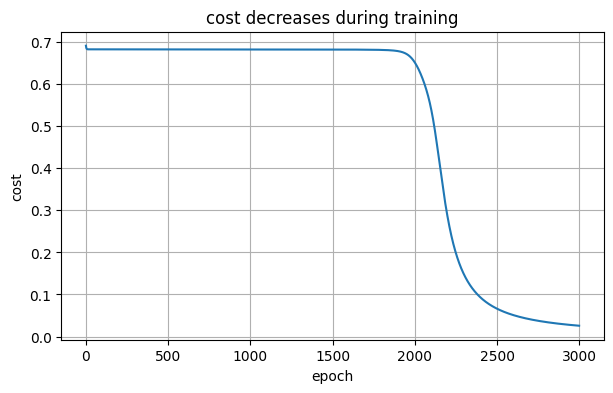

In [18]:
# 학습 후, cost가 실제로 줄었는지 숫자로 확인합니다.
print('first cost:', cost_history[0])
print('last cost:', cost_history[-1])
print('cost decreased:', cost_history[-1] < cost_history[0])

# cost 감소 그래프 (이 노트북에서 허용되는 그래프는 이 1개뿐입니다.)
plt.figure(figsize=(7, 4))
plt.plot(cost_history)
plt.xlabel('epoch')
plt.ylabel('cost')
plt.title('cost decreases during training')
plt.grid(True)
plt.show()

In [19]:
# 학습이 끝난 파라미터로 최종 예측을 확인합니다.
# 예측만 할 때는 gradient가 필요 없으므로 torch.no_grad()안에서 실행합니다.
with torch.no_grad():
    # 히든 뉴런 1
    H_hidden_1 = a11 * X1_norm + a12 * X2_norm + b1
    z_hidden_1 = torch.sigmoid(H_hidden_1)
    
    H_hidden_2 = a21 * X1_norm + a22 * X2_norm + b1
    z_hidden_2 = torch.sigmoid(H_hidden_2)
    
    # 출력층
    H_output = a31 * z_hidden_1 + a32 * z_hidden_2 + b3
    z_output = torch.sigmoid(H_output)
    
    # z_output은 0~1 사이의 예측확률입니다.
    # 예측확률이 0.5 이상이면 1로 판단하고, 0.5 미만이면 0으로 판단합니다.
    
    # (z_output >= 0.5)의 결과는 True/False입니다.
    # .float()를 붙이면 True는 1.0, False는 0.0으로 바뀝니다.
    pred = (z_output >= 0.5).float()
    accuracy = (pred == y_tensor).float().mean()     # 정답과 얼마나 일치하는지 (평균 = 정확도)
    

In [20]:
# 결과 표 만들기
result_df = df[['temperature', 'humidity', 'y']].copy()

# z_output은 PyTorch Tensor입니다.
# 이 Tensor는 autograd 계산 기록과 연결되어 있을 수 있습니다.
# 표에 넣기 위해서는 계산 추적을 끊고 NumPy 배열로 바꿔야 합니다.
z_output_np = z_output.detach().numpy()

# 현재 shape는 (n, 1)입니다.
# DataFrame 컬럼에 넣기 쉽게 (n, ) 형태의 1차원 배열로 바꿉니다.
z_output_1d = z_output_np.reshape(-1)

# 소수점 4자리까지 반올림해서 결과표에 넣습니다.
result_df['z_output'] = z_output_1d.round(4)

# pred도 같은 방식으로 단계별로 나눠서 넣습니다.
pred_np = pred.detach().numpy()
pred_1d = pred_np.reshape(-1)
result_df['pred'] = pred_1d.astype(int)

print('accuracy:', accuracy.item())
result_df

accuracy: 1.0


,temperature,humidity,y,z_output,pred
0,10,30,0,0.0140,0
1,15,40,0,0.0250,0
2,22,50,1,0.9644,1
3,25,55,1,0.9783,1
4,28,60,1,0.9620,1
5,35,70,0,0.0283,0
6,38,80,0,0.0141,0


In [21]:
# 학습이 끝난 최종 파라미터를 표로 확인합니다.
final_params_df = pd.DataFrame({
    'parameters': ['a11', 'a12', 'b1', 'a21', 'a22', 'b2', 'a31', 'a32', 'b3'],
    'value': [
        a11.item(), a21.item(), b1.item(),
        a21.item(), a22.item(), b2.item(),
        a31.item(), a32.item(), b3.item()
    ]
})

final_params_df

,parameters,value
0,a11,-4.123951
1,a12,3.163063
2,b1,-4.572610
3,a21,3.163063
4,a22,3.589820
5,b2,-4.506469
6,a31,-8.238766
7,a32,-8.253270
8,b3,3.975178
